# Lecture 08d — An index that learned itself

**AI-integrated Sustainable Finance (25881) · Lecture 8 lab, part 4**

Notebook 08a built features by hand: NDVI, NBR, MNDWI. Each is a line of algebra
someone wrote down, defensible to an auditor, and limited in documented ways.

This notebook uses features that were **learned instead of written**. Google DeepMind's
AlphaEarth Foundations compresses a year of multi-sensor observation into a 64-dimensional
vector for every 10 m pixel on Earth. Structurally it is still an index: a fixed-dimension
summary of the spectrum, computed once and reused. The difference is where the coefficients
came from.

**Assumed from 08c**: what an embedding is, and that the stored int8 values must be de-quantised through a non-linear map before any dot product means anything. `esgsat.aef_dequantise` does that here.

**Three things you will find out**

1. Whether the unit-norm invariant still holds after a live read, which is the cheapest
   end-to-end correctness test this dataset offers.
2. Whether learned features actually beat hand-crafted ones on the same task, with the same
   classifier and the same labels.
3. That the accuracy you would have reported is probably inflated, because random
   cross-validation leaks across spatially correlated pixels. The honest number is lower.

**Prerequisites:** 08a, 08b and 08c. In particular 08c explains what an embedding is, and covers the non-linear de-quantisation this notebook relies on. This notebook additionally needs `scikit-learn`.

In [1]:
# --- dependencies ----------------------------------------------------------
import importlib, sys

REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "sklearn": "scikit-learn", "rasterio": "rasterio",
            "pyarrow": "pyarrow", "fsspec": "fsspec",
            "xarray": "xarray", "rioxarray": "rioxarray",
            "pystac_client": "pystac-client", "odc.stac": "odc-stac"}

def _missing(d):
    out = []
    for mod, pkg in d.items():
        try:
            importlib.import_module(mod)
        except Exception:
            out.append(pkg)
    return out

need = _missing(REQUIRED)
IN_COLAB = "google.colab" in sys.modules
if need and IN_COLAB:
    import subprocess
    print("Colab detected. Installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *need], check=False)
elif need:
    print("Missing required packages:", " ".join(need))
    print("  Anaconda :  conda install -c conda-forge " + " ".join(need))
    print("  pip      :  pip install " + " ".join(need))
    print("Install, restart the kernel, then re-run.")
else:
    print("All required packages present.")

All required packages present.


In [2]:
import pathlib, urllib.request
HELPER = "esgsat.py"
REPO_RAW = ("https://raw.githubusercontent.com/VitaliAlexeev/"
            "AI_SustainableFinance_2026/main/helpers/esgsat.py")
if not pathlib.Path(HELPER).exists():
    try:
        urllib.request.urlretrieve(REPO_RAW, HELPER)
        print("Downloaded esgsat.py.")
    except Exception as exc:
        print(f"Could not download esgsat.py ({type(exc).__name__}).")

import numpy as np
import matplotlib.pyplot as plt
import esgsat as E

USE_LIVE = True          # set False to force the offline path
AOI_LON, AOI_LAT = 151.21, -33.87     # Sydney
YEAR = 2024
WINDOW_PX = 256          # 256 x 256 at 10 m = 2.56 km across

np.seterr(divide="ignore", invalid="ignore")
plt.rcParams["figure.dpi"] = 110
print(f"AlphaEarth: {E.AEF_BANDS} bands, years {E.AEF_YEARS[0]} to {E.AEF_YEARS[-1]}")

AlphaEarth: 64 bands, years 2017 to 2025


## 1. What this dataset is

Verified anonymously on 1 September 2026, with no Google account and no credentials:

| Property | Value |
|---|---|
| Location | `gs://alphaearth_foundations/satellite_embedding/v1/annual/{year}/{utm_zone}/` |
| Requester-pays | **No.** Google absorbs the egress; you pay nothing |
| Years | 2017 to 2025 inclusive |
| Tile | 8192 × 8192 pixels, 64 bands, **int8**, 10 m pixels |
| Format | Cloud-optimised GeoTIFF, tiled 1024 × 1024, zstd, overviews to 1 × 1 |
| Tile size | 300 MB to 3.2 GB. **Never download one** |
| Index | `aef_index.parquet`, 302,466 rows, with WGS84 bounds per tile |
| Licence | CC-BY 4.0, with required attribution |

The attribution is a licence condition, not a courtesy. Put it on anything you publish:

> *The AlphaEarth Foundations Satellite Embedding dataset is produced by Google and
> Google DeepMind.*

One design consequence to notice before we start. A single tile is up to 3.2 GB, and a
class of thirty cannot download that. But it is a *cloud-optimised* GeoTIFF, so a windowed
read pulls only the 1024 × 1024 blocks that intersect your area — a few megabytes. The
measured open-and-read time for a 256 × 256 window was about one second. **The file format
is what makes this teachable at all.**

## 2. Getting a window of embeddings

Three steps, and the first is the one that makes this practical.

1. **Index lookup.** The published index is 66 MB and 302,466 rows, most of it a geometry
   column we do not need. We read seven columns, filter to one year, and cache the result to
   disk. After the first run this notebook works offline.
2. **Pick the tile** whose WGS84 bounding box contains your point. More than one can match,
   because adjacent UTM zones overlap; take the nearest centre.
3. **Windowed read** over `/vsicurl/`, pulling only the blocks that intersect your window.

If the network is unavailable, the fallback generates synthetic embeddings with the same
dtype, the same no-data sentinel, and the same non-linear quantisation, so every subsequent
cell still runs. Read the warning in section 6 before drawing any conclusion from the
offline numbers.

In [3]:
EMB, SOURCE = None, "synthetic"

if USE_LIVE:
    try:
        idx = E.aef_load_index(year=YEAR)
        print(f"Index: {len(idx):,} tiles for {YEAR}")
        hits = E.aef_find_tiles(idx, AOI_LON, AOI_LAT, year=YEAR)
        print(f"Tiles covering ({AOI_LON}, {AOI_LAT}): {len(hits)}")
        if len(hits):
            row = hits.iloc[0]
            url = E.aef_tile_url(row["path"])
            print(f"Using  {row['utm_zone']}  {url.rsplit('/', 1)[-1]}")
            EMB, TR, CRS = E.aef_read_window(url, AOI_LON, AOI_LAT,
                                             size_px=WINDOW_PX, dequantise=False)
            SOURCE = "live"
    except Exception as exc:
        print(f"Live path unavailable: {type(exc).__name__}: {exc}")

if EMB is None:
    scene = E.demo_scene(size=WINDOW_PX, as_dn=True, cloud=True,
                         noise_sd=0.055, smooth_px=6)
    EMB = E.demo_embedding(scene["SCL"], noise=1.6, smooth_px=6)
    SOURCE = "synthetic"

print(f"\nSource : {SOURCE}")
print(f"Cube   : {EMB.shape}  dtype {EMB.dtype}")
print(f"Stored range: {int(EMB.min())} to {int(EMB.max())}")
print(f"No-data pixels: {float(np.mean(EMB[0] == E.AEF_NODATA))*100:.1f}%")

Index: 34,149 tiles for 2024
Tiles covering (151.21, -33.87): 1
Using  56S  xzner84rkkjdvpdtx-0000000000-0000008192.tiff

Source : live
Cube   : (64, 256, 256)  dtype int8
Stored range: -87 to 90
No-data pixels: 0.0%


In [4]:
# The free correctness test.
X = E.aef_dequantise(EMB)
med, frac = E.aef_check_unit_norm(X)
print(f"median vector norm after de-quantising : {med:.4f}")
print(f"fraction within 2% of 1.0              : {frac*100:.1f}%")

raw = np.where(EMB == E.AEF_NODATA, np.nan, EMB).astype("float32")
med_raw, frac_raw = E.aef_check_unit_norm(raw)
print(f"median norm if you skip de-quantising  : {med_raw:,.1f}   <- nowhere near 1")

assert abs(med - 1.0) < 0.05, "Unit-norm check failed: the read or the de-quantisation is wrong."
print("\nPASS: the embedding vectors are unit length, so the read and the maths are right.")

median vector norm after de-quantising : 1.0001
fraction within 2% of 1.0              : 100.0%
median norm if you skip de-quantising  : 323.7   <- nowhere near 1

PASS: the embedding vectors are unit length, so the read and the maths are right.


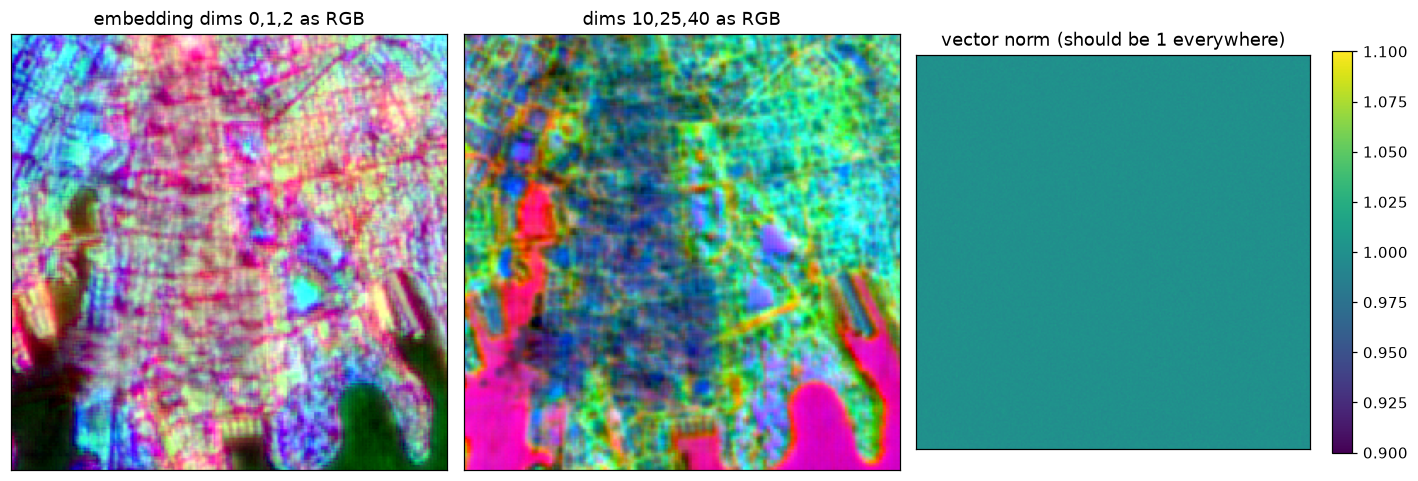

No individual dimension means anything. That is the point, and the problem.

The AlphaEarth Foundations Satellite Embedding dataset is produced by Google and Google DeepMind.


In [5]:
# What does a 64-dimensional image even look like? Take three dimensions as RGB.
def as_rgb(cube, dims=(0, 1, 2)):
    out = np.dstack([cube[d] for d in dims]).astype("float32")
    for i in range(3):
        lo, hi = np.nanpercentile(out[..., i], [2, 98])
        out[..., i] = np.clip((out[..., i] - lo) / max(hi - lo, 1e-9), 0, 1)
    return np.nan_to_num(out)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
axes[0].imshow(as_rgb(X, (0, 1, 2))); axes[0].set_title("embedding dims 0,1,2 as RGB")
axes[1].imshow(as_rgb(X, (10, 25, 40))); axes[1].set_title("dims 10,25,40 as RGB")
im = axes[2].imshow(np.sqrt(np.nansum(X ** 2, axis=0)), cmap="viridis", vmin=0.9, vmax=1.1)
axes[2].set_title("vector norm (should be 1 everywhere)")
fig.colorbar(im, ax=axes[2], fraction=0.046)
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("No individual dimension means anything. That is the point, and the problem.")
print(f"\n{E.AEF_ATTRIBUTION}")

## 3. Labels, and where they come from

Supervision has to come from somewhere. We use the Sentinel-2 **scene classification layer**
as weak labels: water, vegetation, not-vegetated.

Be clear about what that is. SCL is itself the output of a model. So we are training one model
on another model's opinions, and our "accuracy" measures agreement with SCL, not agreement
with the ground. That is a legitimate way to compare two feature sets against each other, and
an illegitimate way to claim either is *correct*.

Label provenance is not a footnote. In a carbon context, the equivalent question is whether
your biomass labels came from field plots, from an allometric model, or from another
satellite product — and the three give very different meanings to the same accuracy figure.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GroupKFold, cross_val_score

if SOURCE == "live":
    try:
        items = E.search_scenes(E.bbox_from_point(AOI_LON, AOI_LAT, 2.0),
                                f"{YEAR}-01-01", f"{YEAR}-12-31", max_cloud=10)
        ds = E.load_bands(items[0], E.bbox_from_point(AOI_LON, AOI_LAT, 2.0),
                          bands=["B02", "B03", "B04", "B08", "B11", "B12"], resolution=10)
        s2 = {b: ds[b].isel(time=0).values for b in ["B02", "B03", "B04", "B08", "B11", "B12"]}
        s2["SCL"] = ds["scl"].isel(time=0).values
    except Exception as exc:
        print(f"Could not fetch matching Sentinel-2 ({type(exc).__name__}); using synthetic.")
        s2 = E.demo_scene(size=WINDOW_PX, as_dn=True, cloud=True)
else:
    s2 = E.demo_scene(size=WINDOW_PX, as_dn=True, cloud=True)

# Crop both sources to a common shape.
h = min(EMB.shape[1], s2["B08"].shape[0]); w = min(EMB.shape[2], s2["B08"].shape[1])
EMB = EMB[:, :h, :w]; X = X[:, :h, :w]
s2 = {k: v[:h, :w] for k, v in s2.items()}

LABEL_MAP = {6: 0, 4: 1, 5: 2}
LABEL_NAME = {0: "water", 1: "vegetation", 2: "not vegetated"}
y = np.full((h, w), -1, dtype=int)
for scl_code, lab in LABEL_MAP.items():
    y[s2["SCL"] == scl_code] = lab

for lab, name in LABEL_NAME.items():
    print(f"  {name:16s} {int(np.sum(y == lab)):7,d} pixels")
print(f"  {'unlabelled':16s} {int(np.sum(y == -1)):7,d} pixels (cloud, shadow, other)")

C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\pystac\extensions\storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


  water             27,361 pixels
  vegetation         8,728 pixels
  not vegetated     29,209 pixels
  unlabelled           238 pixels (cloud, shadow, other)


## 4. Before the comparison: check which path you are on

**If `SOURCE` is `synthetic`, everything in section 6 is circular in both directions and must
not be reported.**

- The synthetic embeddings are generated *from* the labels, so they can only look good.
- The synthetic labels are generated *from* the same endmember spectra the indices measure, so
  the indices predict them perfectly by construction. Expect an accuracy of exactly 1.0000.

That second one is worth sitting with. **A perfect score is a red flag, not a result.** In real
work, 1.0000 almost always means the label leaked into the features, not that the model is
excellent. If you ever see it in your own analysis, go looking for the leak before you
celebrate.

The offline path exists to prove the code runs on a machine with no network. It is not
evidence about the real dataset.

In [7]:
print(f"SOURCE = {SOURCE!r}")
if SOURCE == "synthetic":
    print()
    print("  The accuracy comparison above is CIRCULAR. Do not report it.")
    print("  Re-run with network access before using any of these numbers.")
else:
    print()
    print("  Live data. The comparison is meaningful, subject to the label caveat")
    print("  in section 4: you are measuring agreement with SCL, not with the ground.")

SOURCE = 'live'

  Live data. The comparison is meaningful, subject to the label caveat
  in section 4: you are measuring agreement with SCL, not with the ground.


## 5. Head to head

Same task, same classifier, same labels, same pixels. Only the features differ.

- **Hand-crafted**: six index values per pixel, each with a name and a physical story.
- **Learned**: 64 embedding dimensions per pixel, none of which means anything alone.

In [8]:
rf = {b: E.to_reflectance(s2[b]) for b in s2 if b != "SCL"}
hand_names = ["NDVI", "NDWI", "MNDWI", "NDMI", "NBR", "BSI"]
hand = np.stack([E.compute_index(n, rf) for n in hand_names])

ok = (y >= 0) & np.all(np.isfinite(hand), axis=0) & np.all(np.isfinite(X), axis=0)
rows, cols = np.nonzero(ok)
Xh = hand[:, ok].T
Xe = X[:, ok].T
yy = y[ok]
print(f"usable labelled pixels : {yy.size:,}")
print(f"hand-crafted features  : {Xh.shape[1]}  ({', '.join(hand_names)})")
print(f"learned features       : {Xe.shape[1]}")

# Subsample so this runs in seconds on a laptop.
rng = np.random.default_rng(25881)
take = rng.choice(yy.size, size=min(8000, yy.size), replace=False)
Xh, Xe, yy = Xh[take], Xe[take], yy[take]
rows, cols = rows[take], cols[take]

usable labelled pixels : 65,252
hand-crafted features  : 6  (NDVI, NDWI, MNDWI, NDMI, NBR, BSI)
learned features       : 64


In [9]:
def score(features, groups=None, n_splits=5):
    clf = RandomForestClassifier(n_estimators=60, min_samples_leaf=5,
                                 n_jobs=-1, random_state=0)
    if groups is None:
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=0)
        return cross_val_score(clf, features, yy, cv=cv, n_jobs=1)
    cv = GroupKFold(n_splits=n_splits)
    return cross_val_score(clf, features, yy, cv=cv, groups=groups, n_jobs=1)

rand_hand = score(Xh)
rand_emb  = score(Xe)
print("Random 5-fold cross-validation")
print(f"  hand-crafted indices : {rand_hand.mean():.4f}  (sd {rand_hand.std():.4f})")
print(f"  learned embeddings   : {rand_emb.mean():.4f}  (sd {rand_emb.std():.4f})")
print(f"  difference           : {rand_emb.mean() - rand_hand.mean():+.4f}")

Random 5-fold cross-validation
  hand-crafted indices : 0.8524  (sd 0.0112)
  learned embeddings   : 0.7581  (sd 0.0098)
  difference           : -0.0943


### That number is too good, and here is why

Neighbouring pixels are near-duplicates. A random split puts a pixel in the training fold and
its immediate neighbour in the test fold, so the model is graded on data it has effectively
already seen. The reported accuracy measures **interpolation within the scene**, not the
thing you care about, which is whether the model works somewhere it has not been trained.

The fix is to split by **spatial block**, so entire regions are held out. Same data, same
classifier, honest question.

spatial blocks: 64 of 32x32 pixels

features                  random CV   spatial CV   inflation
------------------------------------------------------------
hand-crafted indices         0.8524       0.8545     -0.0021
learned embeddings           0.7581       0.6276     +0.1305

On the honest split, hand-crafted indices lead by 0.2269.
Random CV overstated the hand-crafted score by -0.0021 and the learned score by +0.1305.


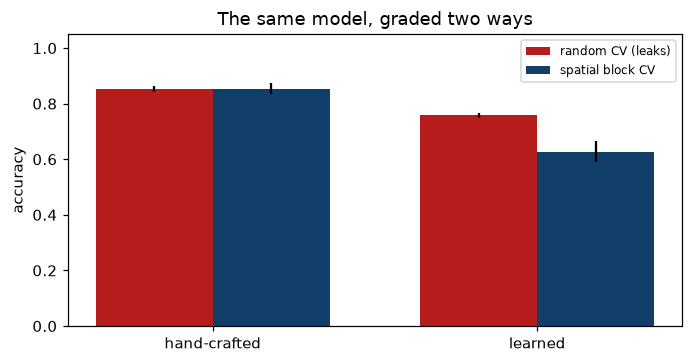

In [10]:
BLOCK_PX = 32
blocks = (rows // BLOCK_PX) * 10_000 + (cols // BLOCK_PX)
print(f"spatial blocks: {len(np.unique(blocks))} of {BLOCK_PX}x{BLOCK_PX} pixels\n")

sp_hand = score(Xh, groups=blocks)
sp_emb  = score(Xe, groups=blocks)

print(f"{'features':22s} {'random CV':>12s} {'spatial CV':>12s} {'inflation':>11s}")
print("-" * 60)
for name, r, s in [("hand-crafted indices", rand_hand, sp_hand),
                   ("learned embeddings", rand_emb, sp_emb)]:
    print(f"{name:22s} {r.mean():12.4f} {s.mean():12.4f} {r.mean()-s.mean():+11.4f}")
print()
gap = sp_emb.mean() - sp_hand.mean()
winner = "learned embeddings" if gap > 0 else "hand-crafted indices"
print(f"On the honest split, {winner} lead by {abs(gap):.4f}.")
for nm, sc_ in [("hand-crafted", sp_hand), ("learned", sp_emb)]:
    if sc_.mean() > 0.999:
        print(f"  WARNING: {nm} scored {sc_.mean():.4f}. A perfect score means a leak, "
              f"not a triumph. Find it before you report it.")
print(f"Random CV overstated the hand-crafted score by {rand_hand.mean()-sp_hand.mean():+.4f} "
      f"and the learned score by {rand_emb.mean()-sp_emb.mean():+.4f}.")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
xpos = np.arange(2)
ax.bar(xpos - 0.18, [rand_hand.mean(), rand_emb.mean()], 0.36,
       yerr=[rand_hand.std(), rand_emb.std()], label="random CV (leaks)", color="#B71C1C")
ax.bar(xpos + 0.18, [sp_hand.mean(), sp_emb.mean()], 0.36,
       yerr=[sp_hand.std(), sp_emb.std()], label="spatial block CV", color="#123F69")
ax.set_xticks(xpos); ax.set_xticklabels(["hand-crafted", "learned"])
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
ax.set_title("The same model, graded two ways")
plt.tight_layout(); plt.show()

## 6. What you gained, what you gave up

| | Hand-crafted index | Learned embedding |
|---|---|---|
| Meaning | Each number has physical content | No dimension means anything alone |
| Auditability | The formula fits on one line | Model weights, training data, version |
| Inputs needed | Just the scene | A pre-trained model, plus labels |
| Accuracy | Saturates, biased by soil and atmosphere | Usually better, sometimes much better |
| Continuity | The formula is permanent | Google may change or withdraw the product |
| Assurance | Explainable to an auditor | An open problem |

The continuity row is not hypothetical. AlphaEarth is a Google product; the README commits to
at least one year's notice of change. Compare that to NDVI, published in 1974 and computable
by anyone, forever, from any sensor with a red and a near-infrared band.

For an AASB S2 assurance engagement, "a model produced this number" is not yet a satisfying
answer. The index is worse and more defensible; the embedding is better and harder to defend.
**That tension is the live question in the field, and it is a good thing to write about.**

## Core exercises

**C1 — Quantify the trap.** Re-run section 5 using **raw int8 values** as the learned features,
skipping de-quantisation. Report the accuracy change. Then explain, in two sentences, why a
tree-based classifier is barely affected while a linear model or any distance-based method
would be badly affected.

**C2 — Find the block size that matters.** Repeat the spatial cross-validation with
`BLOCK_PX` set to 8, 32 and 128. Plot accuracy against block size. At what separation does
the leakage stop? Relate that distance to something physical in your scene.

**C3 — How many dimensions do you actually need?** Fit the classifier on the first 4, 8, 16,
32 and all 64 embedding dimensions. Plot accuracy against dimension count. If 8 dimensions
get you most of the way, what does that tell you about the claim that all 64 are necessary?

## Stretch exercises

**S1 — Change, without a second image.** AlphaEarth publishes one layer per year. Take the
embeddings for 2019 and 2021 over the Blue Mountains area from 08b, and compute the cosine
distance between the two 64-vectors at each pixel. Compare the resulting map with your dNBR
map. Which detects the fire more cleanly, and which would you trust for an area estimate?

**S2 — Labels are the bottleneck.** Halve, quarter and eighth the training set, and plot
accuracy against label count for both feature sets. The usual claim for foundation models is
that they need far fewer labels. Does your curve support it?

**S3 — Carbon, honestly.** Suppose you had 200 field plots with measured above-ground biomass.
Sketch, in code you do not have to run, the pipeline that would fit biomass on embeddings,
including the cross-validation scheme. Then list the three things that would stop you putting
the output in a client report.

**S4 — The continuity risk, priced.** Write a short paragraph for a model risk committee on
what happens to a production carbon model if the embedding provider changes the model version.
Include what you would monitor to detect it.

## Where Lecture 8 leaves you

Across the three notebooks the same shape kept appearing.

- **08a**: stored integers are not physical units, and the conversion is linear.
- **08b**: the satellite was the smallest source of uncertainty; the literature parameters
  dominated; and the counterfactual was not observable at all.
- **08c**: stored integers are not features either, and this time the conversion is
  non-linear — and the accuracy you would have reported was inflated by a split that leaked.

None of these is exotic. All three are the ordinary discipline of knowing what your numbers
mean, applied to a model whose inputs happen to be photons. That discipline is the whole of
the difference between an analysis and a picture.